In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize
from matplotlib.colors import LogNorm
from scipy import integrate
from platosim.matplotlibrc import setup_paper
from tqdm import tqdm
setup_paper()

In [3]:
# Paths to where data is stored
path = '/lhome/nicholas/software/workdir/smbhb'
fdir = '/lhome/nicholas/Nextcloud/paperSMBHB/figures'

The methods below have been adapted directly from D'Orazio(2018) so if you want to see the equations you can see them there.

In [4]:
G = 6.674e-8 #cm^3g^-1s^-2
c = 2.998 * 10**10 #cm/s
h = 6.62607015e-27  # Planck constant in erg·s
k_B = 1.380649e-16  # Boltzmann constant in erg/K

def r_ISCO(M):
    M_g = M * 1.989e33 #total mass in g
    return 6 * G * M_g / c**2 # in cm

def orbital_radius(M, period_rest):
    M_g = M * 1.989e33  # g
    T_s = period_rest * 365.25 * 24 * 3600 #seconds in binary rest frame
    return ((G * M_g * T_s**2) / (4 * np.pi**2))**(1/3) 

def accretion_rate(M):
    radiative_efficiency = 0.1
    M_g = M * 1.989e33  # g
    year_in_sec = 3.1536 * 10 **7 #s
    return 2.26 * 10**-2 * (radiative_efficiency / 0.1) **-1 * (M_g/10**6) / year_in_sec

def Temp(q, r, M):
    M_g = M * 1.989e33  # g
    sigma = 5.67 * 10 **-5 # erg cm^-2s^-1K^-4
    # power = 3 * G * M_g * accretion_rate(M) * (1 - np.sqrt(r_ISCO(M) / r)) / (8 * np.pi * r**3)
    power = 3 * G * q * M_g / (1+q) * accretion_rate(q * M / (1 + q)) * (1 - np.sqrt(r_ISCO(q * M / (1 + q)) / r)) / (8 * np.pi * r**3)
    return (power / sigma)**0.25  

def planck_wavelength(wavelength, T):
    numerator = 2 * h * c**2
    exponent = (h * c) / (wavelength * k_B * T)
    denominator = (wavelength**5) * (np.exp(exponent) - 1)
    return numerator / denominator

def flux(wavelength, r, q, M, period, z):
    period_rest = period / (1 + z)
    a = orbital_radius(M, period_rest)
    r_isco = r_ISCO(q * M / (1 + q))
    condition = (r_isco < r) & (r < 0.27 * a * q**0.3)
    flux_values = np.where(
        condition,
        np.pi * planck_wavelength(wavelength, Temp(q, r, M)),
        0
    )
    return flux_values

def einstein_radius(q, M, I, period, time, z):
    period_rest = period / (1 + z)
    a = orbital_radius(M, period_rest)
    
    M_g = M * 1.989e33  # g
    R_p = 2 * G * M_g / ((1 + q) * c**2) # primary Schwarzchild in cm
    R_s = 2 * G * M_g * q / ((1 + q) * c**2) # primary Schwarzchild in cm
    
    primary = np.sqrt(2 * R_p * a * np.cos(I) * np.sin(2 * np.pi * time / period)) # in cm
    secondary = np.sqrt(2 * R_s * a * np.cos(I) * np.sin(-np.pi + 2 * np.pi * time / period)) # in cm
    return primary, secondary

def position_uv(q, M, I, period, time, z):
    period_rest = period / (1 + z)
    a = orbital_radius(M, period_rest)
    
    if 0 < time / period < 0.5:
        phase = np.sqrt(np.cos(2 * np.pi * time / period) ** 2 + (np.sin(I) ** 2) * np.sin(2 * np.pi * time / period) ** 2)
        # phase = np.cos(2 * np.pi * time / period)
        u_0 = (a * phase / einstein_radius(q, M, I, period, time, z)[0])

    else:
        phase = np.sqrt(np.cos(-np.pi + 2 * np.pi * time / period) ** 2 + np.sin(I) ** 2 * np.sin(-np.pi + 2 * np.pi * time / period) ** 2)
        u_0 = (a * phase / einstein_radius(q, M, I, period, time, z)[1])
        
    v_0 = np.arctan(np.sin(I) * np.tan(2 * np.pi * time / period))
    return u_0, v_0 

def M_point_u(u): #just a dummy function, not point-source magnification
    return (u ** 2 + 2) / (np.sqrt(u**2 + 4))

def r(u, v, u_0, v_0, r_E, J):
    r_star = np.sqrt(u_0 ** 2 + u ** 2 - 2 * u_0 * u * np.cos(v - v_0)) * r_E 
    sin_phi = (u * np.sin(v) - u_0 * np.sin(v_0)) / np.sqrt((u * np.sin(v) - u_0 * np.sin(v_0)) ** 2 + (u * np.cos(v) - u_0 * np.cos(v_0)) ** 2)

    phi = np.arcsin(sin_phi)
    
    #return r_star * np.sqrt(np.cos(phi) ** 2 + np.sin(phi) ** 2 / (np.cos(np.pi / 2 - J) ** 2))
    return r_star * np.sqrt(np.cos(phi) ** 2 + np.sin(phi) ** 2 / (np.cos(np.pi / 2 - J) ** 2)), r_star, phi


def M_point(u): #point-source magnification
    return (u ** 2 + 2) / (u * np.sqrt(u**2 + 4))


## Finite-Source Magnification Light Curve

This part is slightly sensitive to the number of iterations (num1, num2, etc). The numbers below were fine-tuned to my purposes.

In [6]:
N = 1000
time_array = np.linspace(0.92, 1.08, num=N)  
wavelength_array = np.array([150e-7, 230e-7, 550e-7, 806e-7, 3400e-7]) #LSST effective wavelengths
n = len(wavelength_array)
mag_arrays = [[] for _ in range(5)]
Magnification_p =[]

J = np.pi / 4 
I = 0.005 # binary inclination
print(np.rad2deg(I))

0.2864788975654116


In [110]:
N = 86400
time_array = np.linspace(0.96, 1.04, num=N)  
wavelength_array = np.array([550e-7]) #LSST effective wavelengths
n = len(wavelength_array)
mag_arrays = [[] for _ in range(1)]
Magnification_p =[]
J = np.pi / 4
i  = np.arccos(0.040)
I  = 0.005 #np.pi/2 - i
print(np.rad2deg(i), np.rad2deg(I))

87.70755722404411 0.2864788975654116


1.5e-05


Processing time steps:   0%|                                                                                                         | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_2510346/1793445348.py:55: RuntimeWarning: invalid value encountered in sqrt
  secondary = np.sqrt(2 * R_s * a * np.cos(I) * np.sin(-np.pi + 2 * np.pi * time / period)) # in cm
Processing time steps: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1100.92it/s]


2.3e-05


Processing time steps: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1065.52it/s]


5.5e-05


...

8.06e-05


Processing time steps: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1068.97it/s]


0.00034


Processing time steps: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1035.76it/s]


<IPython.core.display.Javascript object>


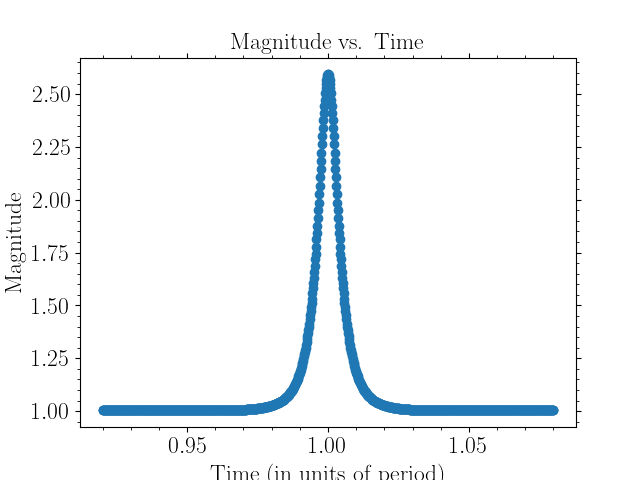

In [7]:
u_max, num1, num2 = 5, 300, 100 
u_array = np.linspace(0, u_max, num1)
delta_u = u_max / num1
v_array = np.linspace(0, 2 * np.pi, num2)
delta_v = 2 * np.pi / num2
u_grid, v_grid = np.meshgrid(u_array, v_array)

for l in range(n):
    wavelength_cm = wavelength_array[l]
    print(wavelength_cm)
    for t in tqdm(time_array, desc="Processing time steps"):
        u_0, v_0 = position_uv(0.1, 10**6, I, 4, t, 0) ##### calculating for q=0.1, M=10**6, T=4yrs, z=0
        r_E = einstein_radius(0.1, 10**6, I, 4, t, 0)[0] ##### calculating for q=0.1, M=10**6, T=4yrs, z=0

        radius = r(u_grid, v_grid, u_0, v_0, r_E, J)[0]
        flux_values = flux(wavelength_cm, radius, 0.1, 10**6, 4, 0) ##### calculating for q=0.1, M=10**6, T=4yrs, z=0
        M_point_u_values = M_point_u(u_grid)

        numer = np.sum(flux_values * M_point_u_values * delta_u * delta_v)
        denom = np.sum(flux_values * u_grid * delta_u * delta_v)

        mag_arrays[l].append(numer / denom)
        
for t in time_array:
    u_0, v_0 = position_uv(0.1, 10**6, I, 4, t, 0) ##### calculating for q=0.1, M=10**6, T=4yrs, z=0
    Magnification_p.append(M_point(u_0))

# Plot the results
plt.figure()
plt.scatter(time_array, mag_arrays[0])
plt.xlabel('Time (in units of period)')
plt.ylabel('Magnitude')
plt.title('Magnitude vs. Time')
plt.show();

In [112]:
df = pd.DataFrame({'time': time_array, 'flux':mag_arrays[0]})
df.to_feather(f'{path}/lensing_model.ftr')

<IPython.core.display.Javascript object>


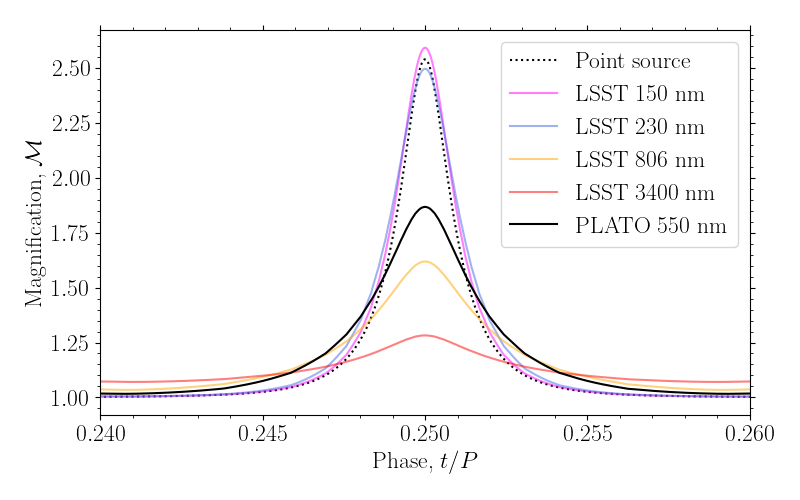

In [10]:
fig = plt.figure(figsize=(8,5))

plt.plot(time_array/4, (Magnification_p), ':',  alpha=1.0, c='k',         label='Point source')
plt.plot(time_array/4, (mag_arrays[0]),   '-',  alpha=0.5, c='magenta',   label='LSST 150 nm')
plt.plot(time_array/4, (mag_arrays[1]),   '-',  alpha=0.5, c='royalblue', label='LSST 230 nm')
plt.plot(time_array/4, (mag_arrays[3]),   '-',  alpha=0.5, c='orange',    label='LSST 806 nm')
plt.plot(time_array/4, (mag_arrays[4]),   '-',  alpha=0.5, c='red',       label='LSST 3400 nm')
plt.plot(time_array/4, (mag_arrays[2]),   '-',  alpha=1.0, c='k',     label='PLATO 550 nm')

# plt.title('$I = 0.28^{\circ}$, $J = 45^{\circ}$')
plt.xlim([0.24, 0.26])
plt.xlabel(r'Phase, $t / P$')
plt.ylabel('Magnification, $\mathcal{M}$')
plt.legend()
plt.tight_layout()
plt.locator_params(axis='x', nbins=5) 

# Save figure
fig.savefig(f'{fdir}/lensing_chromatic.png', bbox_inches='tight', dpi=300)

## Probability of Finite-Source Flares

The code below will take a ~hours to compile.

In [10]:
num3 = 300
I_array = np.linspace(0, 1, num3)
J = np.pi / 2
M_array = np.logspace(5, 9.5, num=50)
z_array = np.linspace(0, 6 , num=50)
period_array = np.linspace(0.5, 5, num=10)
q_array = np.logspace(-0.25, -3.75, num=8)

## u:(320,400) -> 380nm , g:(400,552) -> 476nm , r: (552, 691) -> 622nm , i: (691, 818) -> 755nm , z: (818, 922)-> 870nm , y: (950, 1080) -> 1015nm

def P_finite_source(q, M, period, time, z):
    wavelength_cm = 755 * 10**-7 / (1 + z) # wavelength in binary rest-frame
    time = period / 4
    u_grid, v_grid = np.meshgrid(u_array, v_array)
    
    for I in I_array:
        u_0, v_0 = position_uv(q, M, I, period, time, z)
        r_E = einstein_radius(q, M, I, period, time, z)[0]
        
        radius = r(u_grid, v_grid, u_0, v_0, r_E, J)[0]
        flux_values = flux(wavelength_cm, radius, q, M, period, z)
        M_point_u_values = M_point_u(u_grid)
        
        numer = np.sum(flux_values * M_point_u_values * delta_u * delta_v)
        denom = np.sum(flux_values * u_grid * delta_u * delta_v)
        
        if numer / denom < 1.1:
            return np.degrees(I) / 90

    return 0  

from joblib import Parallel, delayed

def compute_row(q, M, period, z):
    return P_finite_source(q, M, period, period/4, z)

def compute_for_q(q, period_array, M_array, z_array):
    results = []
    for T in tqdm(period_array, desc=f"T={period_array}", leave=False):
        for M in M_array:
            for z in z_array:
                results.append(compute_row(q, M, T, z))
    return results

P_finite = Parallel(n_jobs=-1)(delayed(compute_for_q)(q, period_array, M_array, z_array) for q in q_array)
P_finite = np.array(P_finite).reshape(8, 10, 50, 50)
# np.save('P_finite_i_band.npy', P_finite)

T=[0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]:   0%|          | 0/10 [00:00<?, ?it/s]/var/folders/nc/vpj3jx516wbfyb_vfccc7gph0000gn/T/ipykernel_18251/2739173721.py:66: RuntimeWarning: invalid value encountered in sqrt
/var/folders/nc/vpj3jx516wbfyb_vfccc7gph0000gn/T/ipykernel_18251/2739173721.py:66: RuntimeWarning: invalid value encountered in sqrt
/var/folders/nc/vpj3jx516wbfyb_vfccc7gph0000gn/T/ipykernel_18251/2739173721.py:66: RuntimeWarning: invalid value encountered in sqrt
/var/folders/nc/vpj3jx516wbfyb_vfccc7gph0000gn/T/ipykernel_18251/2739173721.py:66: RuntimeWarning: invalid value encountered in sqrt
/var/folders/nc/vpj3jx516wbfyb_vfccc7gph0000gn/T/ipykernel_18251/2739173721.py:66: RuntimeWarning: invalid value encountered in sqrt
T=[0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]:   0%|          | 0/10 [00:00<?, ?it/s]/var/folders/nc/vpj3jx516wbfyb_vfccc7gph0000gn/T/ipykernel_18251/2739173721.py:66: RuntimeWarning: invalid value encountered in sqrt
/var/folders/nc/vpj3jx516wbfyb_vfccc